## 1. Load and Preprocess the MNIST Data


In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

- ### Load the MNIST Dataset

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


- ### Normalize the input data

In [4]:
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255


- ### Flatten the images

In [5]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

- ### One-hot encoder

In [10]:
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

## 2. Build the MLP Model

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Create the model
model = Sequential()
# Add input layer and first hidden layer
model.add(Dense(512, input_shape=(784,), activation='relu'))
# Add second hidden layer
model.add(Dense(256, activation='relu'))
# Add output layer
model.add(Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 3. Compile and Train the Model

In [12]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy',
metrics=['accuracy'])
# Summarize the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=128,
validation_split=0.2)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9235 - loss: 0.2590 - val_accuracy: 0.9617 - val_loss: 0.1250
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9710 - loss: 0.0952 - val_accuracy: 0.9707 - val_loss: 0.0926
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9818 - loss: 0.0580 - val_accuracy: 0.9737 - val_loss: 0.0907
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9875 - loss: 0.0394 - val_accuracy: 0.9744 - val_loss: 0.0883
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9912 - loss: 0.0277 - val_accuracy: 0.9735 - val_loss: 0.0837
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9923 - loss: 0.0228 - val_accuracy: 0.9769 - val_loss: 0.0905
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9935 - loss: 0.0187 - val_accuracy: 0.9769 - val_loss: 0.0883
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.9952 - loss: 0.0147 - val_accu

## 4. Evaluate the Model

In [14]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9788 - loss: 0.0880
Test accuracy: 0.9787999987602234


## 5. Save the Model

In [15]:
model.save('mnist_mlp_model.h5')

## 6. Load and Use the Model for Prediction


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predicted class: [7]


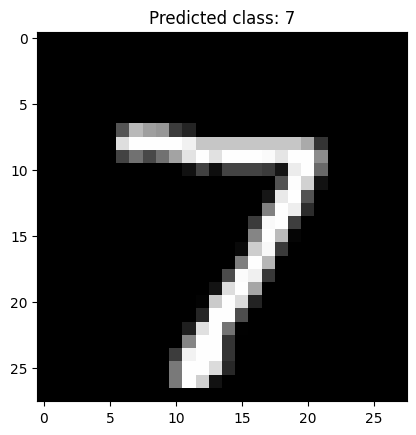

In [16]:
# Load the model
loaded_model = tf.keras.models.load_model('mnist_mlp_model.h5')
# Predict on a test sample
import numpy as np
# Pick a test sample
sample = X_test[0].reshape(1, -1)
# Predict the class
prediction = loaded_model.predict(sample)
predicted_class = np.argmax(prediction, axis=1)
print(f"Predicted class: {predicted_class}")
# Display the test sample
plt.imshow(X_test[0].reshape(28, 28), cmap='gray')
plt.title(f"Predicted class: {predicted_class[0]}")
plt.show()
